# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. um baseline de regressão logística;
2. uma Deep Neural Network (DNN).

## Imports

In [109]:
import re
from collections import Counter
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from activation import ReLUActivation, SigmoidActivation, SoftmaxActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy, CategoricalCrossEntropy
from neuralnetwork import NeuralNetwork
from model_pytorch import train_pytorch_model, predict_pytorch

## Dataset

In [110]:
df = pd.read_csv("../datasetFinal/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,INTEGRAL monitoring of the Galactic Plane is r...,human,0
1,Satellite altimetry ice sheet mass balance est...,Anthropic,2
2,The shares shall be repurchased through public...,human,0
3,The study of coherent correlation spectroscopy...,openai,4
4,Circulating tumor cell epithelial-mesenchymal ...,Anthropic,2


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15544 entries, 0 to 15543
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Text         15544 non-null  object
 1   source_name  15544 non-null  object
 2   source_code  15544 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 364.4+ KB


In [112]:
df["source_name"].value_counts()

source_name
human        7580
openai       2415
google       1897
meta         1838
Anthropic    1814
Name: count, dtype: int64

In [ ]:
df_treino = pd.read_csv("../data/dataset_treino.csv")
df_val = pd.read_csv("../data/dataset_validacao.csv")
df_teste = pd.read_csv("../data/dataset_teste.csv")

# 2. Recriar a coluna 'binary_label' que o vosso código usa (0 para humano, 1 para IA)
df_treino["binary_label"] = (df_treino["source_name"] != "human").astype(int)
df_val["binary_label"] = (df_val["source_name"] != "human").astype(int)
df_teste["binary_label"] = (df_teste["source_name"] != "human").astype(int)

print(f"Treino: {len(df_treino)} | Validação: {len(df_val)} | Teste: {len(df_teste)}")

Treino: 10880 | Validação: 2332 | Teste: 2332


## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [114]:
df["binary_label"] = (df["source_name"] != "human").astype(int)

# 3. Dataset for llm classes
df_llm_only = df[df["source_name"] != "human"].copy()
llm_mapping = {"openai": 0, "google": 1, "meta": 2, "anthropic": 3}
df_llm_only["llm_label"] = df_llm_only["source_name"].map(llm_mapping)

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

In [115]:
print("Binary distribution:")
print(df["binary_label"].value_counts())
print("\nLLMs distribution:")
print(df_llm_only["source_name"].value_counts())

Binary distribution:
binary_label
1    7964
0    7580
Name: count, dtype: int64

LLMs distribution:
source_name
openai       2415
google       1897
meta         1838
Anthropic    1814
Name: count, dtype: int64


## Visualização Gráfica

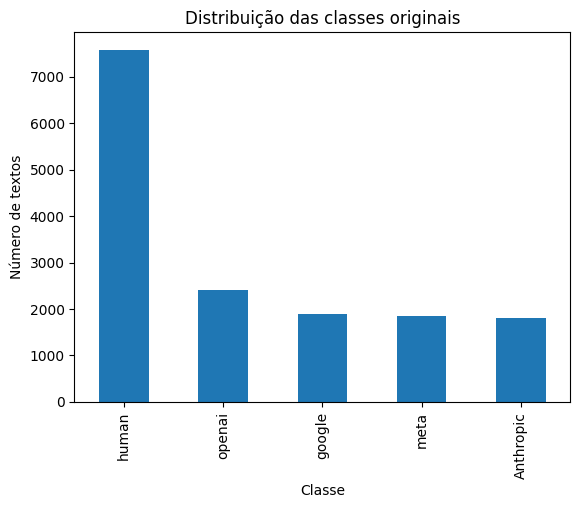

In [116]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

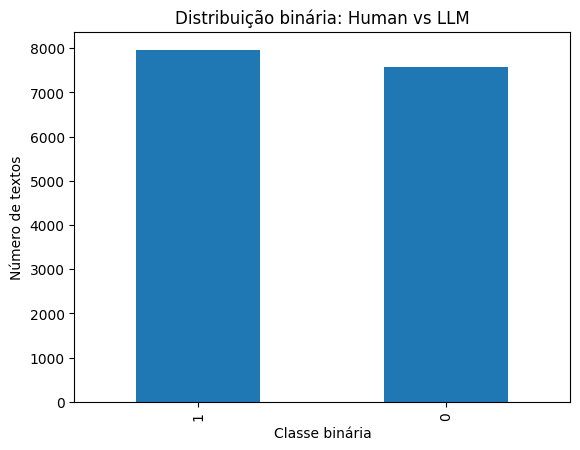

In [117]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

Os textos são extraídos para uma variável de entrada e os rótulos binários para uma variável alvo. A partir daqui, os dados serão divididos em treino e teste, e posteriormente convertidos em representações numéricas.

Separação estratificada simples, proporção entre as classes no conjunto de treino e no conjunto de teste.

In [124]:
# def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    # rng = np.random.default_rng(random_state)

    # class_0_idx = np.where(y == 0)[0]
    # class_1_idx = np.where(y == 1)[0]

    # rng.shuffle(class_0_idx)
    # rng.shuffle(class_1_idx)

    # n0_test = int(len(class_0_idx) * test_size)
    # n1_test = int(len(class_1_idx) * test_size)

    # test_idx = np.concatenate([class_0_idx[:n0_test], class_1_idx[:n1_test]])
    # train_idx = np.concatenate([class_0_idx[n0_test:], class_1_idx[n1_test:]])

    # rng.shuffle(train_idx)
    # rng.shuffle(test_idx)

    # return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train_text = df_treino["Text"].fillna('').astype(str).values
X_test_text = df_teste["Text"].fillna('').astype(str).values
X_val_text = df_val["Text"].fillna('').astype(str).values # Extraído e guardado

y_train_bin = df_treino["binary_label"].values
y_test_bin = df_teste["binary_label"].values
y_val_bin = df_val["binary_label"].values # Extraído e guardado


# --- 2. Extração para o Modelo 2 (Multi-classe LLMs - PyTorch) ---
# Filtrar apenas as linhas que são IA (binary_label == 1)
df_treino_llm = df_treino[df_treino["binary_label"] == 1].copy()
df_teste_llm = df_teste[df_teste["binary_label"] == 1].copy()
df_val_llm = df_val[df_val["binary_label"] == 1].copy() # Validação para LLM

# Mapeamento das classes LLM (0, 1, 2, 3)
llm_mapping = {"openai": 0, "google": 1, "meta": 2, "anthropic": 3} 

# CORREÇÃO: Primeiro limpa (lower, strip), DEPOIS mapeia (.map)
df_treino_llm["llm_label"] = df_treino_llm["source_name"].astype(str).str.lower().str.strip().map(llm_mapping)
df_teste_llm["llm_label"] = df_teste_llm["source_name"].astype(str).str.lower().str.strip().map(llm_mapping)
df_val_llm["llm_label"] = df_val_llm["source_name"].astype(str).str.lower().str.strip().map(llm_mapping)

# CORREÇÃO: Remover valores nulos (NaN) para o PyTorch não dar aquele erro assustador do -9223372036854775808
df_treino_llm = df_treino_llm.dropna(subset=["llm_label"])
df_teste_llm = df_teste_llm.dropna(subset=["llm_label"])
df_val_llm = df_val_llm.dropna(subset=["llm_label"])

# Criar as variáveis (Treino e Teste) que o resto do código do grupo já usa
X_train_llm_text = df_treino_llm["Text"].fillna('').astype(str).values
X_test_llm_text = df_teste_llm["Text"].fillna('').astype(str).values
X_val_llm_text = df_val_llm["Text"].fillna('').astype(str).values # Extraído e guardado

# CORREÇÃO: Extrair as labels e convertê-las IMEDIATAMENTE para inteiros (int64)
y_train_llm = np.array(df_treino_llm["llm_label"].values, dtype=np.int64)
y_test_llm = np.array(df_teste_llm["llm_label"].values, dtype=np.int64)
y_val_llm = np.array(df_val_llm["llm_label"].values, dtype=np.int64) # Extraído e guardado


# --- 3. Prints de Confirmação ---
print("--- Modelo 1 (Binário) ---")
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))
print("Val size:", len(X_val_text))

print("\n--- Modelo 2 (Multi-classe LLMs) ---")
print("Train size llm:", len(X_train_llm_text))
print("Test size llm:", len(X_test_llm_text))
print("Val size llm:", len(X_val_llm_text))


y_train_llm = np.array(y_train_llm, dtype=np.int64)
X_train_llm = np.array(X_train_llm, dtype=np.float32)


--- Modelo 1 (Binário) ---
Train size: 10880
Test size: 2332
Val size: 2332

--- Modelo 2 (Multi-classe LLMs) ---
Train size llm: 5574
Test size llm: 1195
Val size llm: 1195


1. tokenização e normalização do texto;
2. remoção de stopwords;
3. construção do vocabulário a partir do conjunto de treino;
4. cálculo do IDF para cada termo;
5. vetorização TF-IDF dos textos de treino e teste.

In [125]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at", "for", "with",
    "is", "are", "was", "were", "be", "been", "being", "this", "that", "these",
    "those", "it", "its", "as", "by", "from", "but", "about", "into", "than",
    "then", "so", "such", "if", "their", "there", "they", "them", "he", "she",
    "you", "your", "we", "our", "i", "my", "me", "his", "her", "what", "which",
    "who", "whom", "can", "could", "should", "would", "do", "does", "did", "have",
    "has", "had", "not", "no", "yes", "will", "just"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-zA-ZÀ-ÿ]{2,}\b", text)
    return [tok for tok in tokens if tok not in STOPWORDS]

def build_vocabulary(texts, max_features=5000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_features)
    vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
    return vocab

def compute_idf(tokenized_texts, vocab):
    n_docs = len(tokenized_texts)
    df_counts = np.zeros(len(vocab), dtype=np.float64)

    for tokens in tokenized_texts:
        unique_tokens = set(tok for tok in tokens if tok in vocab)
        for tok in unique_tokens:
            df_counts[vocab[tok]] += 1

    idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
    return idf

def vectorize_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)

    for i, text in enumerate(texts):
        tokens = [tok for tok in tokenize(text) if tok in vocab]
        if not tokens:
            continue

        counts = Counter(tokens)
        total_terms = len(tokens)

        for tok, count in counts.items():
            j = vocab[tok]
            tf = count / total_terms
            X[i, j] = tf * idf[j]

    return X

def l2_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + eps)

vocab = build_vocabulary(X_train_text, max_features=5000)

train_tokens = [tokenize(text) for text in X_train_text]
idf = compute_idf(train_tokens, vocab)

X_train = vectorize_tfidf(X_train_text, vocab, idf)
X_test = vectorize_tfidf(X_test_text, vocab, idf)

X_train_llm = vectorize_tfidf(X_train_llm_text, vocab, idf)
X_test_llm = vectorize_tfidf(X_test_llm_text, vocab, idf)

X_train = l2_normalize_rows(X_train)
X_test = l2_normalize_rows(X_test)

X_train_llm = l2_normalize_rows(X_train_llm)
X_test_llm+l2_normalize_rows(X_test_llm)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_llm shape:", X_train_llm.shape)
print("X_test_llm shape:", X_test_llm.shape)

Vocabulary size: 5000
X_train shape: (10880, 5000)
X_test shape: (2332, 5000)
X_train_llm shape: (5574, 5000)
X_test_llm shape: (1195, 5000)


In [126]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train_bin)
test_data = SimpleDataset(X_test, y_test_bin)

In [127]:
input_dim = X_train_llm.shape[1]
model_pytorch = train_pytorch_model(X_train_llm, y_train_llm, input_dim, 4)

A iniciar o treino (4 classes)...
Epochs: [10/50], Perda: 1.0386
Epochs: [20/50], Perda: 0.5122
Epochs: [30/50], Perda: 0.3082
Epochs: [40/50], Perda: 0.2070
Epochs: [50/50], Perda: 0.1485


# Baseline: Regressão Logística

Binary Cross-Entropy como função de perda.

In [128]:
baseline_model = NeuralNetwork(
    epochs=80,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=8
)

baseline_model.add(DenseLayer(1, input_shape=(X_train.shape[1],), initialization="xavier"))
baseline_model.add(SigmoidActivation())

In [129]:
baseline_model.fit(train_data)

Epoch 1/80 - loss: 0.6929
Epoch 2/80 - loss: 0.6928
Epoch 3/80 - loss: 0.6927
Epoch 4/80 - loss: 0.6926
Epoch 5/80 - loss: 0.6925
Epoch 6/80 - loss: 0.6924
Epoch 7/80 - loss: 0.6923
Epoch 8/80 - loss: 0.6922
Epoch 9/80 - loss: 0.6921
Epoch 10/80 - loss: 0.6921
Epoch 11/80 - loss: 0.6920
Epoch 12/80 - loss: 0.6919
Epoch 13/80 - loss: 0.6918
Epoch 14/80 - loss: 0.6917
Epoch 15/80 - loss: 0.6917
Epoch 16/80 - loss: 0.6916
Epoch 17/80 - loss: 0.6915
Epoch 18/80 - loss: 0.6914
Epoch 19/80 - loss: 0.6914
Epoch 20/80 - loss: 0.6913
Epoch 21/80 - loss: 0.6912
Epoch 22/80 - loss: 0.6911
Epoch 23/80 - loss: 0.6911
Epoch 24/80 - loss: 0.6910
Epoch 25/80 - loss: 0.6909
Epoch 26/80 - loss: 0.6908
Epoch 27/80 - loss: 0.6908
Epoch 28/80 - loss: 0.6907
Epoch 29/80 - loss: 0.6906
Epoch 30/80 - loss: 0.6905
Epoch 31/80 - loss: 0.6905
Epoch 32/80 - loss: 0.6904
Epoch 33/80 - loss: 0.6903
Epoch 34/80 - loss: 0.6903
Epoch 35/80 - loss: 0.6902
Epoch 36/80 - loss: 0.6901
Epoch 37/80 - loss: 0.6900
Epoch 38/8

In [130]:
y_pred_prob_baseline = baseline_model.predict(test_data)
y_pred_baseline = (y_pred_prob_baseline >= 0.5).astype(int).flatten()

In [131]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def classification_report_manual(y_true, y_pred):
    precision_0 = precision_score_manual(1 - y_true, 1 - y_pred)
    recall_0 = recall_score_manual(1 - y_true, 1 - y_pred)
    f1_0 = f1_score_manual(1 - y_true, 1 - y_pred)
    support_0 = np.sum(y_true == 0)

    precision_1 = precision_score_manual(y_true, y_pred)
    recall_1 = recall_score_manual(y_true, y_pred)
    f1_1 = f1_score_manual(y_true, y_pred)
    support_1 = np.sum(y_true == 1)

    print("Classe\tPrecision\tRecall\t\tF1-score\tSupport")
    print(f"human\t{precision_0:.4f}\t\t{recall_0:.4f}\t\t{f1_0:.4f}\t\t{support_0}")
    print(f"LLM\t{precision_1:.4f}\t\t{recall_1:.4f}\t\t{f1_1:.4f}\t\t{support_1}")

baseline_accuracy = accuracy_score_manual(y_test_bin, y_pred_baseline)
baseline_precision = precision_score_manual(y_test_bin, y_pred_baseline)
baseline_recall = recall_score_manual(y_test_bin, y_pred_baseline)
baseline_f1 = f1_score_manual(y_test_bin, y_pred_baseline)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.5643224699828473
Precision: 0.5406264185201998
Recall: 0.9966527196652719
F1-score: 0.7010005885815186


## DNN(NumPy)

- camada densa intermédia;
- ativação ReLU;
- dropout como técnica de regularização;
- camada de saída com ativação sigmoide.

In [132]:
model = NeuralNetwork(
    epochs=100,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=10
)

model.add(DenseLayer(64, input_shape=(X_train.shape[1],), l2_lambda=1e-4, initialization="he"))
model.add(ReLUActivation())
model.add(DropoutLayer(0.2))
model.add(DenseLayer(1, l2_lambda=1e-4, initialization="xavier"))
model.add(SigmoidActivation())

In [134]:
model.fit(train_data)

Epoch 1/100 - loss: 0.6915
Epoch 2/100 - loss: 0.6915
Epoch 3/100 - loss: 0.6914
Epoch 4/100 - loss: 0.6914
Epoch 5/100 - loss: 0.6912
Epoch 6/100 - loss: 0.6912
Epoch 7/100 - loss: 0.6912
Epoch 8/100 - loss: 0.6910
Epoch 9/100 - loss: 0.6908
Epoch 10/100 - loss: 0.6909
Epoch 11/100 - loss: 0.6908
Epoch 12/100 - loss: 0.6908
Epoch 13/100 - loss: 0.6907
Epoch 14/100 - loss: 0.6907
Epoch 15/100 - loss: 0.6906
Epoch 16/100 - loss: 0.6906
Epoch 17/100 - loss: 0.6905
Epoch 18/100 - loss: 0.6904
Epoch 19/100 - loss: 0.6903
Epoch 20/100 - loss: 0.6903
Epoch 21/100 - loss: 0.6901
Epoch 22/100 - loss: 0.6901
Epoch 23/100 - loss: 0.6901
Epoch 24/100 - loss: 0.6900
Epoch 25/100 - loss: 0.6900
Epoch 26/100 - loss: 0.6899
Epoch 27/100 - loss: 0.6899
Epoch 28/100 - loss: 0.6897
Epoch 29/100 - loss: 0.6896
Epoch 30/100 - loss: 0.6895
Epoch 31/100 - loss: 0.6895
Epoch 32/100 - loss: 0.6894
Epoch 33/100 - loss: 0.6894
Epoch 34/100 - loss: 0.6892
Epoch 35/100 - loss: 0.6890
Epoch 36/100 - loss: 0.6891
E

In [135]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.51492063]
 [0.50796243]
 [0.517007  ]
 [0.51463708]
 [0.51627912]
 [0.51364453]
 [0.49192199]
 [0.52211513]
 [0.53291001]
 [0.50950958]]
[1 1 1 1 1 1 0 1 1 1]


In [136]:
dnn_accuracy = accuracy_score_manual(y_test_bin, y_pred)
dnn_precision = precision_score_manual(y_test_bin, y_pred)
dnn_recall = recall_score_manual(y_test_bin, y_pred)
dnn_f1 = f1_score_manual(y_test_bin, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1-score:", dnn_f1)

print("\nClassification report:")
classification_report_manual(y_test_bin, y_pred)

cm = confusion_matrix_manual(y_test_bin, y_pred)
print("\nConfusion matrix:")
print(cm)

Accuracy: 0.5960548885077187
Precision: 0.5599810336652442
Recall: 0.9882845188284519
F1-score: 0.7148910411622276

Classification report:
Classe	Precision	Recall		F1-score	Support
human	0.9372		0.1838		0.3074		1137
LLM	0.5600		0.9883		0.7149		1195

Confusion matrix:
[[ 209  928]
 [  14 1181]]


In [137]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (NumPy)", "DNN (NumPy)"],
    "Accuracy": [baseline_accuracy, dnn_accuracy],
    "Precision": [baseline_precision, dnn_precision],
    "Recall": [baseline_recall, dnn_recall],
    "F1-score": [baseline_f1, dnn_f1]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (NumPy),0.564322,0.540626,0.996653,0.701001
1,DNN (NumPy),0.596055,0.559981,0.988285,0.714891


O DNN atingiu o melhor desempenho global, com um F1-score de 0.77, em comparação com o 0.71 da baseline de regressão logistica.

Ambos os modelos atingiram um recall alto na deteção de texto gerado por IA. O DNN aumentou a precision, fruto de um melhor equilíbrio entre falsos positivos e falsos negativos.

## Curvas de Treino

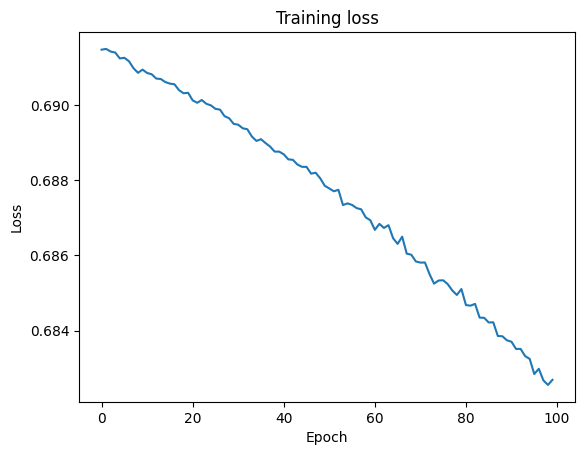

In [138]:
plt.plot(model.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

# Modelo em Pytorch

In [139]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [140]:
from models.model_pytorch import (
    train_pytorch_model,
    predict_pytorch,
    save_pytorch_model,
    load_pytorch_model
)

### Verificar Shape e Labels

In [141]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_bin shape:", y_train_bin.shape)
print("y_test_bin shape:", y_test_bin.shape)

X_train shape: (10880, 5000)
X_test shape: (2332, 5000)
y_train_bin shape: (10880,)
y_test_bin shape: (2332,)


### Treino

In [142]:
pytorch_model = train_pytorch_model(
    X_train=X_train,
    y_train=y_train_bin,
    input_dim=X_train.shape[1],
    n_classes=1,
    epochs=20
)

A iniciar o treino (1 classes)...
Epochs: [10/20], Perda: 0.4832
Epochs: [20/20], Perda: 0.2179


### Guardar Modelo

In [143]:
save_pytorch_model(pytorch_model, "../models/pytorch_binary_model.pt")

Modelo PyTorch guardado em ../models/pytorch_binary_model.pt


### Previsões

In [144]:
y_pred_pytorch = predict_pytorch(
    model=pytorch_model,
    X_test=X_test,
    n_classes=1
).flatten()

### Avaliação

In [145]:
y_true_pytorch = y_test_bin.flatten()

pytorch_accuracy = accuracy_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_precision = precision_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_recall = recall_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_f1 = f1_score_manual(y_true_pytorch, y_pred_pytorch)

print("PyTorch Accuracy:", pytorch_accuracy)
print("PyTorch Precision:", pytorch_precision)
print("PyTorch Recall:", pytorch_recall)
print("PyTorch F1-score:", pytorch_f1)

PyTorch Accuracy: 0.8992281303602059
PyTorch Precision: 0.8697996918335902
PyTorch Recall: 0.9447698744769875
PyTorch F1-score: 0.905736060970718


In [148]:
# ==========================================
# MODELO PYTORCH 2: MULTICLASSE
# ==========================================

X_train_llm_pt = np.array(X_train_llm, dtype=np.float32)
X_test_llm_pt = np.array(X_test_llm, dtype=np.float32)

y_train_llm_pt = np.array(y_train_llm, dtype=np.int64)
y_test_llm_pt = np.array(y_test_llm, dtype=np.int64)

print("X_train_llm shape:", X_train_llm_pt.shape)
print("y_train_llm shape:", y_train_llm_pt.shape)

X_train_llm shape: (5574, 5000)
y_train_llm shape: (5574,)


In [150]:
# 2. Treinar o modelo Multiclasse
input_dim_llm = X_train_llm_pt.shape[1]

pytorch_model_llm = train_pytorch_model(
    X_train=X_train_llm_pt,
    y_train=y_train_llm_pt,
    input_dim=input_dim_llm,
    n_classes=4, 
    epochs=80
)

A iniciar o treino (4 classes)...
Epochs: [10/80], Perda: 1.0193
Epochs: [20/80], Perda: 0.5240
Epochs: [30/80], Perda: 0.3331
Epochs: [40/80], Perda: 0.2180
Epochs: [50/80], Perda: 0.1541
Epochs: [60/80], Perda: 0.1154
Epochs: [70/80], Perda: 0.0908
Epochs: [80/80], Perda: 0.0738


In [151]:
save_pytorch_model(pytorch_model_llm, "../models/pytorch_multiclass_llm_model.pt")

Modelo PyTorch guardado em ../models/pytorch_multiclass_llm_model.pt


In [ ]:
# Fazer Previsões
y_pred_pytorch_llm = predict_pytorch(
    model=pytorch_model_llm,
    X_test=X_test_llm_pt,
    n_classes=4
).flatten()

In [153]:
pytorch_llm_accuracy = np.mean(y_test_llm_pt == y_pred_pytorch_llm)

print(f"\nPyTorch LLM (Multi-classe) Accuracy: {pytorch_llm_accuracy * 100:.2f}%")


PyTorch LLM (Multi-classe) Accuracy: 87.11%


### Comparação

In [147]:
print("\nComparison of models")
print("------------------------------")
print(f"Baseline NumPy   | Acc: {baseline_accuracy:.4f} | Prec: {baseline_precision:.4f} | Rec: {baseline_recall:.4f} | F1: {baseline_f1:.4f}")
print(f"DNN NumPy        | Acc: {dnn_accuracy:.4f} | Prec: {dnn_precision:.4f} | Rec: {dnn_recall:.4f} | F1: {dnn_f1:.4f}")
print(f"DNN PyTorch      | Acc: {pytorch_accuracy:.4f} | Prec: {pytorch_precision:.4f} | Rec: {pytorch_recall:.4f} | F1: {pytorch_f1:.4f}")


Comparison of models
------------------------------
Baseline NumPy   | Acc: 0.5643 | Prec: 0.5406 | Rec: 0.9967 | F1: 0.7010
DNN NumPy        | Acc: 0.5961 | Prec: 0.5600 | Rec: 0.9883 | F1: 0.7149
DNN PyTorch      | Acc: 0.8992 | Prec: 0.8698 | Rec: 0.9448 | F1: 0.9057
